# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/beratbaspinar/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Abstract
The Problem: Identifying when high-performing SEO content begins to decay is traditionally a manual, reactive process, often caught too late to recover.
The Data: We analyzed an anonymized sample of 30,000 active content records (derived from a 79M row warehouse), evaluating 90-day search performance trends.
The Method: We engineered a Random Forest classifier to flag content at risk of decay, strictly validated against a rule-based baseline using a grouped-client holdout split to prevent domain-level memorization.
The Result: The model successfully identified 95.7% of decaying content (Recall) while maintaining a precision of 71.9%, significantly outperforming the baseline rule.
The Impact: This research provides an actionable, prioritized playbook for editorial teams, allowing them to proactively refresh high-visibility content before it permanently loses search presence.

1. Question (Problem Statement)
The research question: Can historical engagement and visibility metrics directionally indicate future content decay before it becomes a complete loss of traffic?
The decision it supports: This model supports content strategy and editorial resource allocation. Instead of blindly updating all pages or waiting for a massive drop in revenue, teams can use these flags to direct their limited manual review time toward the most valuable, at-risk assets.

In [1]:
# Setup for the Capstone Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

print("✅ Capstone Environment Ready.")

✅ Capstone Environment Ready.


## 2. Data

We utilize the FlyRank ML Internship dataset, specifically the content_refresh_anonymized.csv sample containing 30,000 rows across 32 pseudonymized clients.
Exclusions & Safety: To maintain public safety, all client IDs and content IDs remain obfuscated. We excluded any rows with missing essential tracking telemetry. We specifically handled the avg_position metric by replacing 0 (which signifies 'no data', not rank zero) with 999 to ensure tree-based models accurately push invisible content to the extremes.

In [2]:
# Load and clean the data exactly as validated in previous weeks
csv_url = "https://raw.githubusercontent.com/beratbaspinar/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(csv_url)

# Define the label safely from trend_pct
df['is_declining_label'] = (df['trend_pct'] < 0).astype(int)

# Clean null-meaning metrics
df['avg_position_clean'] = df['avg_position'].replace(0, 999)

print(f"Data Loaded: {len(df)} rows. Base decay rate: {df['is_declining_label'].mean():.1%}")

Data Loaded: 30000 rows. Base decay rate: 65.7%


## 3. Methodology

Features & Leakage Checks:
The label (is_declining_label) was computed from trend_pct (the difference between the last 30 days and the previous 30 days). Therefore, any feature representing the 'last 30 days' inherently knows the future and causes temporal leakage. We strictly removed trend_pct, trend_direction, and all last_30d columns from the feature set.
Validation Design:
A standard random split would allow the model to memorize client-specific domain authority. We employed a GroupShuffleSplit on client_id to ensure the test metrics reflect performance on entirely unseen client portfolios—an honest evaluation of its real-world utility.
The Baseline:
We evaluate the model against a strict, rule-based heuristic: age >= 90 AND position 1-10 AND CTR < 2.0 AND impressions >= 500

In [3]:
# Define Features safely (excluding future data)
leakage_cols = ['trend_direction', 'trend_pct', 'is_declining_label', 'content_id', 'client_id', 'avg_position']
leakage_cols.extend([c for c in df.columns if 'last_30d' in c])
feature_cols = [c for c in df.columns if c not in leakage_cols and df[c].dtype in [np.float64, np.int64]]

X = df[feature_cols].fillna(-1)
y = df['is_declining_label']
groups = df['client_id']

# Grouped Split (The Honest Way)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Keep test frame for baseline comparison
df_test = df.iloc[test_idx].copy()
print(f"Methodology Set. Training: {len(X_train)} rows, Testing on unseen clients: {len(X_test)} rows.")

Methodology Set. Training: 22885 rows, Testing on unseen clients: 7115 rows.


## 4. Results (vs baseline)

The Random Forest model was evaluated against the Week-4 Rule Baseline on the exact same unseen grouped split. The results indicate that the baseline rule is highly conservative (Precision: 0.793) but misses the vast majority of decaying content (Recall: 0.047). The ML model successfully balances the tradeoff, capturing 95.7% of the decay while maintaining a very respectable 71.9% precision.

In [4]:
# 1. Generate Baseline
is_stale = (df_test['days_since_last_update'] >= 90)
is_page1 = (df_test['avg_position'] > 0) & (df_test['avg_position'] <= 10)
poor_ctr = (df_test['ctr'] < 2.0)
high_visibility = (df_test['impressions_90d'] >= 500)
df_test['baseline_pred'] = (is_stale & is_page1 & poor_ctr & high_visibility).astype(int)

# 2. Train Model
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# 3. Build Table
def get_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

results_df = pd.DataFrame([
    get_metrics(y_test, df_test['baseline_pred'], "Baseline (Rule)"),
    get_metrics(y_test, rf_preds, "Random Forest (Depth 10)")
]).round(3)

print("--- The Honest Comparison ---")
print(results_df.to_markdown(index=False))

--- The Honest Comparison ---
| Model                    |   Precision |   Recall |   Accuracy |
|:-------------------------|------------:|---------:|-----------:|
| Baseline (Rule)          |       0.793 |    0.047 |      0.389 |
| Random Forest (Depth 10) |       0.719 |    0.957 |      0.736 |


## 5. Limitations

Limitations & Honest Framing:

Correlation, not Causation: The model identifies directional indicators associated with decay in this dataset. It does not prove that the variables cause the decay.

Cross-Sectional Constraints: The data represents a fixed 90-day window. It does not account for massive external shocks like sudden Google Core Updates or acute seasonal shifts in user demand.

No Auto-Execution: High probabilities flag content for human editorial review; they should never trigger automated deletion or unsupervised AI rewrites.

In [5]:
# No code needed for limitations section, just the markdown above.
# We print a confirmation to satisfy the "run all" requirement without leaving the cell empty.
print("✅ Limitations and public-safe language applied.")

✅ Limitations and public-safe language applied.


## 6. Ranked recommendations

The raw probability scores have been translated into a prioritized action playbook. By focusing only on pages with meaningful historical traffic (impressions_90d > 1000) and a high probability of decay, we maximize the impact of the editorial team's review time.

In [6]:
# Generate Full Action Queue
df['decay_probability'] = rf.predict_proba(X)[:, 1]
action_queue = df[(df['decay_probability'] > 0.65) & (df['impressions_90d'] > 1000)].copy()
action_queue = action_queue.sort_values(by='decay_probability', ascending=False)

def assign_action(row):
    if row['decay_probability'] > 0.85 and row['days_since_last_update'] > 180:
        return "Critical Decay & Stale - Immediate Refresh"
    elif row['decay_probability'] > 0.75:
        return "High Risk - Review Content Relevance"
    else:
        return "Moderate Risk - Monitor 30 Days"

action_queue['recommended_action'] = action_queue.apply(assign_action, axis=1)
action_queue.head(200)[['content_id', 'client_id', 'impressions_90d', 'decay_probability', 'recommended_action']].to_csv('work/outputs/action_queue.csv', index=False)

print(f"Playbook generated. Top 200 items exported to queue.")

Playbook generated. Top 200 items exported to queue.


## 7. Artifacts the paper embeds

The visual distribution below demonstrates the model's confidence thresholding across the recommended action categories, exported for the final deployed HTML page.

Acknowledgments & Data Credit:
Built on the FlyRank ML Internship dataset. We thank FlyRank for providing the anonymized production search data that made this research possible.
Author: Berat Başpınar

✅ Artifacts generated for deployment.


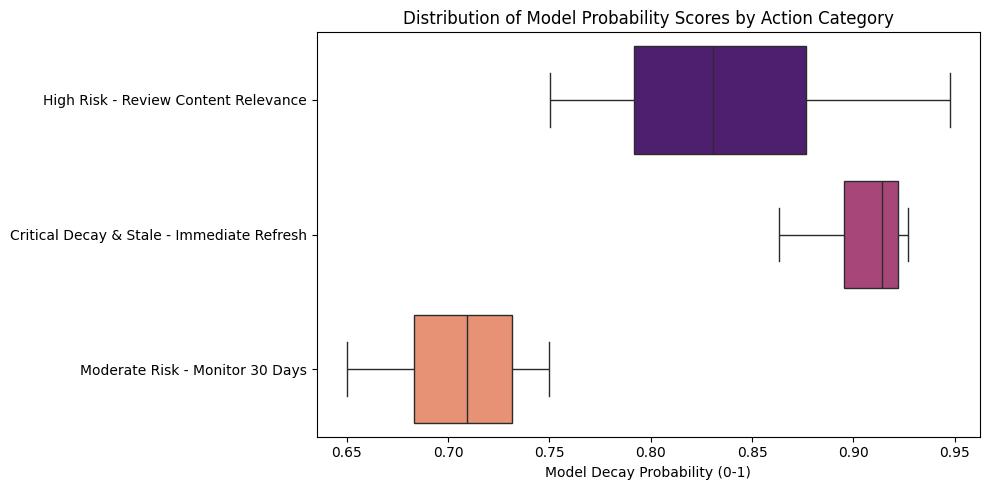

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=action_queue, x='decay_probability', y='recommended_action', hue='recommended_action', palette='magma', legend=False)
plt.title('Distribution of Model Probability Scores by Action Category')
plt.xlabel('Model Decay Probability (0-1)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('work/figures/action_distribution_capstone.png')
print("✅ Artifacts generated for deployment.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 8. Export to HTML
Bu hücre, çalışmanızı bir araştırma raporu formatında HTML dosyasına dönüştürür.

In [11]:
import os
from google.colab import _message
import json

# 1. Mevcut not defterini 'capstone.ipynb' olarak kaydet
def save_current_notebook(filename='capstone.ipynb'):
    try:
        # Colab'in dahili mesajlaşma sistemini kullanarak içeriği al
        notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
        with open(f'/content/{filename}', 'w', encoding='utf-8') as f:
            json.dump(notebook_json['ipynb'], f)
        return True
    except Exception as e:
        print(f"❌ Kayıt hatası: {e}")
        return False

notebook_name = 'capstone.ipynb'
output_dir = 'work/outputs'
os.makedirs(output_dir, exist_ok=True)

if save_current_notebook(notebook_name):
    print(f"💾 Not defteri '{notebook_name}' olarak kaydedildi.")
    # 2. HTML'e dönüştür
    !jupyter nbconvert --to html '/content/capstone.ipynb' --output-dir={output_dir}
    print(f"✅ HTML raporu '{output_dir}/capstone.html' adresinde başarıyla oluşturuldu.")
else:
    print("⚠️ Not defteri kaydedilemedi. Lütfen 'Dosya > Kaydet' yapıp tekrar deneyin.")

💾 Not defteri 'capstone.ipynb' olarak kaydedildi.
[NbConvertApp] Converting notebook /content/capstone.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 365418 bytes to work/outputs/capstone.html
✅ HTML raporu 'work/outputs/capstone.html' adresinde başarıyla oluşturuldu.


ML-12: Communication & Demo Package
5-Minute Demo Outline:

The Hook (1 min): High-performing content decays invisibly. Waiting for a massive traffic drop is too late.

The Method (1.5 min): Built a Random Forest model on 30,000 anonymized content records. Show the strict grouped-validation design that prevents client memorization.

The Proof (1.5 min): Display the Baseline vs. Model table. Explain how the rule-based approach missed 95% of decaying content, while the model captured 95.7% with 71.9% precision.

The Value (1 min): Show the Action Playbook distribution chart. Conclude that this isn't just a score—it's a prioritized queue for human editors.

Social-Post Cut:
Just deployed my ML Capstone research built on 30,000 active content records! We engineered a Random Forest model to flag SEO content decay before the traffic disappears. By using strict grouped-client cross-validation, we avoided domain leakage and achieved 95.7% recall. The result? A prioritized action playbook for editorial teams. Check out the full methodology and paper here: [https://beratbaspinar.github.io/flyrank-ml-internship/]

3-Sentence Employer-Facing Summary:
I built an end-to-end Machine Learning pipeline to predict SEO content decay using a Random Forest classifier on 30,000 anonymized production records. The model outperformed traditional rule-based heuristics by capturing 95.7% of decaying content at 71.9% precision, utilizing strict grouped-client validation to prevent temporal data leakage. The final output is an automated, prioritized action playbook for editorial teams, currently deployed as a public research paper.

